In [1]:
import neural_lam as nl
import weather_model_graphs as wmg
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fp_datastore_config = "../../tests/datastore_examples/mdp/danra_100m_winds/danra.datastore.yaml"
datastore = nl.datastore.init_datastore(config_path=fp_datastore_config, datastore_kind="mdp")


2025-04-04 17:49:07.114 | WARNING  | neural_lam.datastore.mdp:__init__:64 - Config file has been modified since zarr was created. The old zarr archive (in ../../tests/datastore_examples/mdp/danra_100m_winds/danra.datastore.zarr) will be used.To generate new zarr-archive, move the old one first.


The loaded datastore contains the following features:
 state   : u100m v100m
 forcing : swavr0m
 static  : lsm orography
With the following splits (over time):
 train   : 2022-04-01T00:00 to 2022-04-04T00:00
 val     : 2022-04-04T00:00 to 2022-04-07T00:00
 test    : 2022-04-07T00:00 to 2022-04-10T00:00


In [3]:
xy_coords = datastore.get_xy(category="state", stacked=False)
xy_coords

array([[[-894248.19322605, -142041.20913295],
        [-894248.19322605, -139541.20913295],
        [-894248.19322605, -137041.20913295],
        ...,
        [-894248.19322605,   50458.79086705],
        [-894248.19322605,   52958.79086705],
        [-894248.19322605,   55458.79086705]],

       [[-891748.19322605, -142041.20913295],
        [-891748.19322605, -139541.20913295],
        [-891748.19322605, -137041.20913295],
        ...,
        [-891748.19322605,   50458.79086705],
        [-891748.19322605,   52958.79086705],
        [-891748.19322605,   55458.79086705]],

       [[-889248.19322605, -142041.20913295],
        [-889248.19322605, -139541.20913295],
        [-889248.19322605, -137041.20913295],
        ...,
        [-889248.19322605,   50458.79086705],
        [-889248.19322605,   52958.79086705],
        [-889248.19322605,   55458.79086705]],

       ...,

       [[-661748.19322605, -142041.20913295],
        [-661748.19322605, -139541.20913295],
        [-661748.19322

In [4]:
n = None
xy_stacked = np.stack([xy_coords[:n, :n,i].flatten() for i in [0,1]], axis=1)
xy_stacked.shape

(7680, 2)

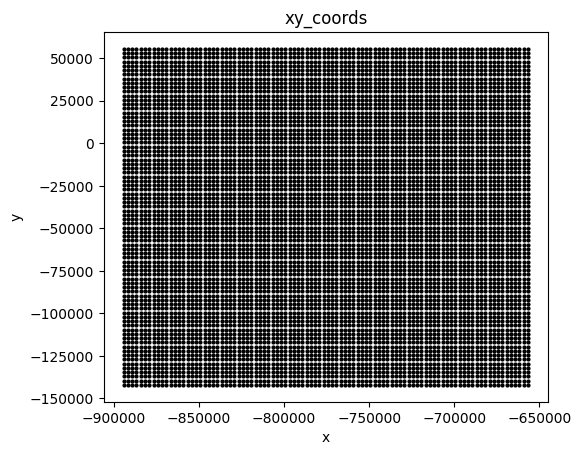

In [5]:
fig, ax = plt.subplots()
ax.set_title("xy_coords")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect('equal')
ax.plot(xy_stacked[:,0], xy_stacked[:,1], "o", color="black", markersize=2)

In [6]:
graph = wmg.create.archetype.create_keisler_graph(coords=xy_stacked, mesh_node_distance=1e4)

2025-04-04 17:49:07.243 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:91 - No `coords_crs` given: Assuming `coords` contains in-projection Cartesian coordinates.


In [7]:
import networkx as nx
import operator
from collections import defaultdict

LOOKUPS = {
    'exact': operator.eq,
    'lt': operator.lt,
    'lte': operator.le,
    'gt': operator.gt,
    'gte': operator.ge,
    'contains': lambda a, b: b in a,
    'in': lambda a, b: a in b,
    'startswith': lambda a, b: str(a).startswith(b),
    'endswith': lambda a, b: str(a).endswith(b),
    'isnull': lambda a, b: (a is None) if b else (a is not None),
}


def _parse_lookup(key):
    parts = key.split('__')
    if len(parts) == 1:
        return parts[0], 'exact'
    return '__'.join(parts[:-1]), parts[-1]


def _match(attrs, key, value):
    attr, lookup = _parse_lookup(key)
    if lookup not in LOOKUPS:
        raise ValueError(f"Unsupported lookup: {lookup}")
    attr_val = attrs.get(attr, None)
    return LOOKUPS[lookup](attr_val, value)


class Q:
    def __init__(self, **kwargs):
        self.children = [kwargs]
        self.connector = 'AND'
        self.negated = False

    def __or__(self, other):
        return self._combine(other, 'OR')

    def __and__(self, other):
        return self._combine(other, 'AND')

    def __invert__(self):
        q = Q()
        q.children = self.children
        q.connector = self.connector
        q.negated = not self.negated
        return q

    def _combine(self, other, connector):
        q = Q()
        q.children = [self, other]
        q.connector = connector
        return q


def _evaluate_q_object(q, attrs):
    if isinstance(q, dict):
        return all(_match(attrs, k, v) for k, v in q.items())

    results = []
    for child in q.children:
        if isinstance(child, Q):
            result = _evaluate_q_object(child, attrs)
        else:
            result = all(_match(attrs, k, v) for k, v in child.items())
        results.append(result)

    combined = all(results) if q.connector == 'AND' else any(results)
    return not combined if q.negated else combined


def filter_graph(graph: nx.DiGraph, *args, **kwargs):
    """
    Filter nodes and/or edges of a graph using Django-style lookups with Q() support.
    
    Returns:
        dict: {'nodes': [...], 'edges': [...]}
    """
    filters = defaultdict(list)

    # Handle **kwargs
    for k, v in kwargs.items():
        if '__' not in k:
            raise ValueError(f"Query key must start with 'node__' or 'edge__': {k}")
        prefix, rest = k.split('__', 1)
        if prefix not in ('node', 'edge'):
            raise ValueError(f"Unknown filter target: {prefix}")
        filters[prefix].append(Q(**{rest: v}))

    # Handle *args (Q objects)
    for q in args:
        if not isinstance(q, Q):
            raise ValueError("Positional args must be Q objects")
        # Traverse Q object and sort into node/edge filters
        def classify_q(q):
            if isinstance(q, Q):
                new_q = Q()
                new_q.connector = q.connector
                new_q.negated = q.negated
                new_q.children = [classify_q(c) for c in q.children]
                return new_q
            elif isinstance(q, dict):
                classified = defaultdict(dict)
                for k, v in q.items():
                    prefix, rest = k.split('__', 1)
                    classified[prefix][rest] = v
                return {k: Q(**v) for k, v in classified.items()}
        split_q = classify_q(q)
        for prefix in ['node', 'edge']:
            if prefix in split_q:
                filters[prefix].append(split_q[prefix])

    result = {}

    if 'node' in filters:
        result['nodes'] = [
            n for n, attrs in graph.nodes(data=True)
            if all(_evaluate_q_object(q, attrs) for q in filters['node'])
        ]

    if 'edge' in filters:
        result['edges'] = [
            (u, v) for u, v, attrs in graph.edges(data=True)
            if all(_evaluate_q_object(q, attrs) for q in filters['edge'])
        ]

    return result

import re

INDEX_RE = re.compile(r"([^\[]+)(\[[^\]]+\])*")

def _get_nested_attr_value(attrs, key):
    """
    Get attribute value from attrs dict using keys like 'embedding[0][1]'.
    """
    match = INDEX_RE.match(key)
    if not match:
        return attrs.get(key)

    attr_name = match.group(1)
    indices = re.findall(r'\[([0-9]+)\]', key)

    val = attrs.get(attr_name)
    for idx in indices:
        if val is None:
            return None
        try:
            val = val[int(idx)]
        except (IndexError, TypeError):
            return None
    return val


def _match(attrs, key, value):
    attr, lookup = _parse_lookup(key)
    if lookup not in LOOKUPS:
        raise ValueError(f"Unsupported lookup: {lookup}")
    attr_val = _get_nested_attr_value(attrs, attr)
    return LOOKUPS[lookup](attr_val, value)

def filter_graph(graph: nx.DiGraph, *args, **kwargs) -> nx.DiGraph:
    """
    Returns a new DiGraph containing nodes/edges that match the filters.
    """
    filters = defaultdict(list)

    # Handle kwargs
    for k, v in kwargs.items():
        if '__' not in k:
            raise ValueError(f"Query key must start with 'node__' or 'edge__': {k}")
        prefix, rest = k.split('__', 1)
        if prefix not in ('node', 'edge'):
            raise ValueError(f"Unknown filter target: {prefix}")
        filters[prefix].append(Q(**{rest: v}))

    # Handle Q objects in *args
    for q in args:
        if not isinstance(q, Q):
            raise ValueError("Positional args must be Q objects")

        def classify_q(q):
            if isinstance(q, Q):
                new_q = Q()
                new_q.connector = q.connector
                new_q.negated = q.negated
                new_q.children = [classify_q(c) for c in q.children]
                return new_q
            elif isinstance(q, dict):
                classified = defaultdict(dict)
                for k, v in q.items():
                    prefix, rest = k.split('__', 1)
                    classified[prefix][rest] = v
                return {k: Q(**v) for k, v in classified.items()}

        split_q = classify_q(q)
        for prefix in ['node', 'edge']:
            if prefix in split_q:
                filters[prefix].append(split_q[prefix])

    # Filter nodes
    node_match = set()
    if 'node' in filters:
        node_match = {
            n for n, attrs in graph.nodes(data=True)
            if all(_evaluate_q_object(q, attrs) for q in filters['node'])
        }

    # Filter edges
    edge_match = set()
    if 'edge' in filters:
        edge_match = {
            (u, v) for u, v, attrs in graph.edges(data=True)
            if all(_evaluate_q_object(q, attrs) for q in filters['edge'])
        }

    # Build new graph based on what's been filtered
    H = nx.DiGraph()

    if node_match and edge_match:
        for u, v in edge_match:
            if u in node_match and v in node_match:
                H.add_node(u, **graph.nodes[u])
                H.add_node(v, **graph.nodes[v])
                H.add_edge(u, v, **graph.edges[u, v])

    elif node_match:
        H = graph.subgraph(node_match).copy()

    elif edge_match:
        nodes_in_edges = set(u for u, _ in edge_match) | set(v for _, v in edge_match)
        H.add_nodes_from((n, graph.nodes[n]) for n in nodes_in_edges)
        H.add_edges_from(((u, v, graph.edges[u, v]) for u, v in edge_match))

    else:
        H.add_nodes_from(graph.nodes(data=True))
        H.add_edges_from(graph.edges(data=True))

    return H



In [8]:
subgraph = filter_graph(graph, **{"node__pos[0]__lt": -850000, "node__pos[1]__gt": 0})
len(subgraph.nodes)

434

<Axes: >

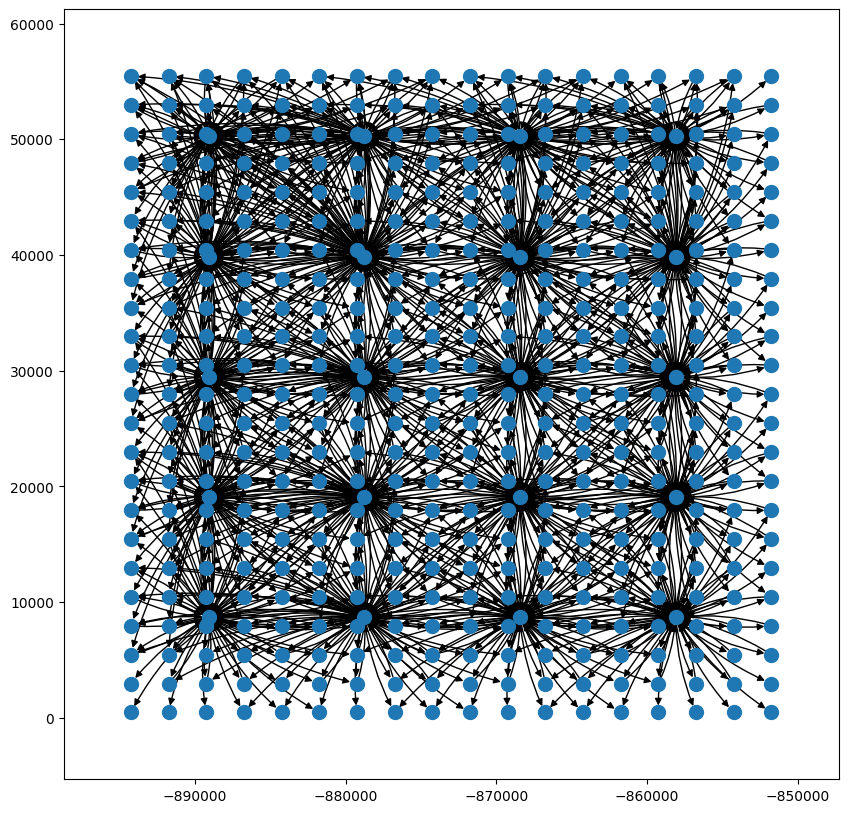

In [9]:
wmg.visualise.nx_draw_with_pos_and_attr(
    graph=subgraph
)